# Day 6 — Behavioral graph, combine, and cluster

Signal 3: catches "careful" rings that deliberately rotate card/address/email per account (evading the identity graph) but still behave the same way operationally — similar amounts, similar timing, similar velocity.

**`isFraud` is still not used anywhere in this notebook.** Both graphs and the clustering are built blind to the label; Day 7 is the first time fraud labels are looked at, purely to evaluate what blind clustering produced.

In [1]:
import sys, time, json
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity

from src.data import load_merged_train
from src.graph import load_graph, save_graph, combine_graphs, cluster_graph
from src.behavioral import (
    build_behavioral_graph, _scaled_features, BEHAVIORAL_FEATURES,
    DEFAULT_TIME_BUCKET_SECONDS, DEFAULT_SIMILARITY_THRESHOLD, BEHAVIORAL_WEIGHT_MULTIPLIER,
)

train = load_merged_train()
print(train.shape)

(590540, 434)


## 1. Choosing a similarity threshold

"Suspiciously similar" needs a defensible cutoff, not a guessed number. Transactions are grouped into 15-minute buckets (bursts, not the full 6-month timeline), and cosine similarity is computed between every pair of transactions *within the same bucket*, on standardized behavioral features (`TransactionAmt` + `C1-C14` + `D1-D15`). Before picking a threshold, look at what that similarity distribution actually looks like on a sample of buckets.

In [2]:
scaled = _scaled_features(train)
buckets = (train['TransactionDT'] // DEFAULT_TIME_BUCKET_SECONDS).astype(int)
print('bucket count:', buckets.nunique(), '| avg bucket size:', round(len(train) / buckets.nunique(), 1))

rng = np.random.default_rng(42)
sample_buckets = rng.choice(buckets.unique(), size=200, replace=False)
sims_all = []
for b in sample_buckets:
    idx = buckets[buckets == b].index
    if len(idx) < 2:
        continue
    vecs = scaled.loc[idx].to_numpy()
    sims = cosine_similarity(vecs)
    iu, ju = np.triu_indices(len(idx), k=1)
    sims_all.append(sims[iu, ju])
sims_all = np.concatenate(sims_all)

print(f'\nSampled {len(sims_all):,} same-bucket pairs from 200 buckets')
print(pd.Series(sims_all).describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.999]))

bucket count: 17305 | avg bucket size: 34.1

Sampled 170,526 same-bucket pairs from 200 buckets
count    170526.000000
mean          0.134226
std           0.491035
min          -0.911203
50%           0.060365
90%           0.866656
95%           0.935112
99%           0.993572
99.9%         1.000000
max           1.000000
dtype: float64


**Reading this:** the *median* same-bucket pair has near-zero similarity (0.06) — most transactions that just happen to occur close in time look nothing alike behaviorally, as expected. Only the top ~1% of pairs exceed 0.99. A threshold of **0.98** (just above the 99th percentile) is used — selective enough that it isn't catching ordinary coincidental closeness, while still being data-justified rather than an arbitrary round number.

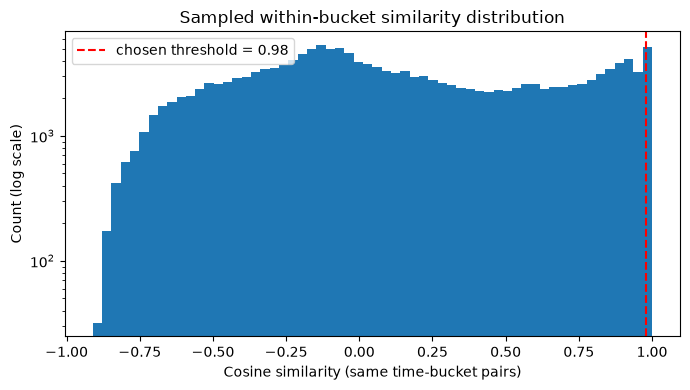

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sims_all, bins=60)
ax.axvline(DEFAULT_SIMILARITY_THRESHOLD, color='red', linestyle='--', label=f'chosen threshold = {DEFAULT_SIMILARITY_THRESHOLD}')
ax.set_yscale('log')
ax.set_xlabel('Cosine similarity (same time-bucket pairs)')
ax.set_ylabel('Count (log scale)')
ax.set_title('Sampled within-bucket similarity distribution')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Build the behavioral graph

- **Features**: `TransactionAmt` (log-transformed) + `C1-C14` (Vesta's identity-count features) + `D1-D15` (time-delta/velocity features) — no new data, all already in the dataset (see [Dataset](../docs/dataset.md)).
- **Bucketing**: 15-minute time buckets, so only transactions close in time are ever compared — comparing all 590K×590K pairs directly is infeasible, and bursts are the whole point.
- **Weight = similarity × 0.2.** Similarity is a *suspicion*, not proof, unlike a shared identifier — deliberately weighted lower so it contributes less than identity evidence when the two graphs are combined.

In [4]:
t0 = time.time()
behavioral_graph = build_behavioral_graph(train)
t1 = time.time()

print(f'Built in {t1 - t0:.1f}s')
print('Nodes:', behavioral_graph.number_of_nodes())
print('Edges:', behavioral_graph.number_of_edges())
non_isolated = sum(1 for _, d in behavioral_graph.degree() if d > 0)
print(f'Non-isolated nodes: {non_isolated:,} ({non_isolated / behavioral_graph.number_of_nodes():.1%})')

Built in 13.0s
Nodes: 590540
Edges: 287183
Non-isolated nodes: 214,559 (36.3%)


## 3. How much does the behavioral layer add beyond the identity graph?

Before touching labels at all, check structurally: how many behavioral edges connect a pair of transactions that **share no identity-graph edge** — i.e. accounts with completely different card/address/email, caught only by matching behavior. This is the structural version of the plan's headline metric for this layer (Day 7 will check whether these actually turn out to concentrate real fraud).

In [5]:
identity_graph = load_graph('../data/processed/identity_graph.pkl')

behavioral_only_edges = sum(
    1 for u, v in behavioral_graph.edges()
    if not identity_graph.has_edge(u, v)
)
total_behavioral_edges = behavioral_graph.number_of_edges()

print(f'Behavioral edges with no matching identity edge: {behavioral_only_edges:,} / {total_behavioral_edges:,} '
      f'({behavioral_only_edges / total_behavioral_edges:.1%})')

identity_connected = {n for n, d in identity_graph.degree() if d > 0}
behavioral_connected = {n for n, d in behavioral_graph.degree() if d > 0}
behavioral_only_nodes = behavioral_connected - identity_connected

print(f'Transactions connected only via behavior (isolated in identity graph): {len(behavioral_only_nodes):,}')

Behavioral edges with no matching identity edge: 270,451 / 287,183 (94.2%)
Transactions connected only via behavior (isolated in identity graph): 123,336


## 4. Combine and cluster

The two graphs are unioned (summing weight where an edge exists in both), then clustered with Louvain community detection — a standard, well-benchmarked algorithm, not a custom one. Using `networkx`'s built-in Louvain implementation rather than adding the separate `python-louvain` package: same algorithm, one fewer dependency.

In [6]:
combined_graph = combine_graphs(identity_graph, behavioral_graph)
print('Combined graph — nodes:', combined_graph.number_of_nodes(), '| edges:', combined_graph.number_of_edges())

t0 = time.time()
partition = cluster_graph(combined_graph, seed=42)
t1 = time.time()
print(f'Louvain clustering done in {t1 - t0:.1f}s')

Combined graph — nodes: 590540 | edges: 1073904


Louvain clustering done in 61.1s


Total clusters: 265,011
Non-trivial clusters (size > 1): 40,451
Largest cluster size: 4,187
Median non-trivial cluster size: 2


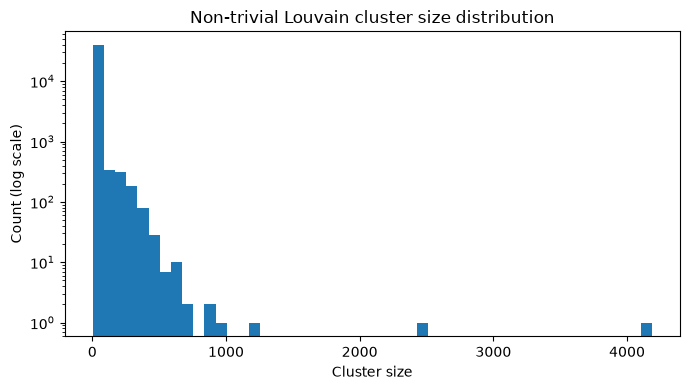

In [7]:
cluster_sizes = pd.Series(partition.values()).value_counts()
non_trivial = cluster_sizes[cluster_sizes > 1]

print(f'Total clusters: {len(cluster_sizes):,}')
print(f'Non-trivial clusters (size > 1): {len(non_trivial):,}')
print(f'Largest cluster size: {cluster_sizes.max():,}')
print(f'Median non-trivial cluster size: {non_trivial.median():.0f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(non_trivial, bins=50)
ax.set_yscale('log')
ax.set_xlabel('Cluster size')
ax.set_ylabel('Count (log scale)')
ax.set_title('Non-trivial Louvain cluster size distribution')
plt.tight_layout()
plt.show()

## 5. Save for Day 7 evaluation

In [8]:
save_graph(behavioral_graph, '../data/processed/behavioral_graph.pkl')
save_graph(combined_graph, '../data/processed/combined_graph.pkl')

with open('../data/processed/cluster_partition.json', 'w') as f:
    json.dump({str(k): v for k, v in partition.items()}, f)

print('Saved behavioral_graph.pkl, combined_graph.pkl, cluster_partition.json to data/processed/')

Saved behavioral_graph.pkl, combined_graph.pkl, cluster_partition.json to data/processed/


## Takeaway

_Fill in after running: how many transactions the behavioral layer connects independently of the identity graph, how many clusters resulted from combining both graphs, and how that cluster-size distribution compares to the identity-only components from Day 5._